<h1 align="center">Codebasics ML Course: Polynomial Regression Tutorial</h1>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("car_prices.csv")
df.head(3)

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928


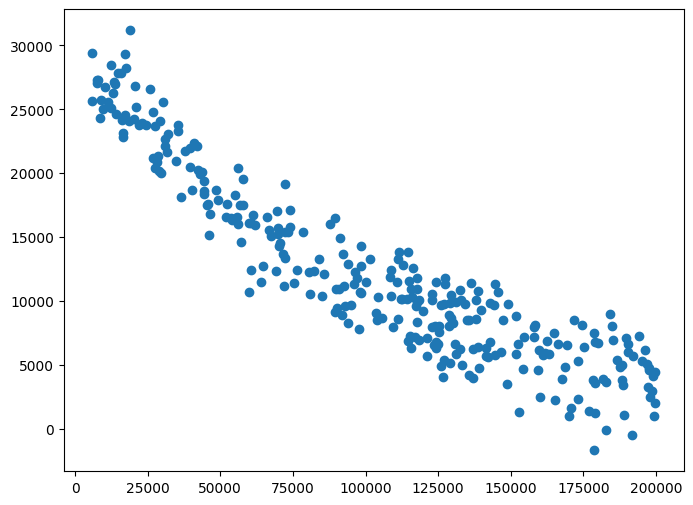

In [16]:
from matplotlib import pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df.mileage, df.selling_price)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X = df[['mileage']]
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [4]:
X.shape, X_test.shape

((300, 1), (60, 1))

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
#Capture non-linearity: Linear regression can only model straight lines. Polynomial features let it fit curves.
      # You can adjust the degree based on model performance
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [6]:
X_train[:10]

,mileage
102,44504
108,43660
96,125151
294,64040
11,131324
106,134312
186,194125
107,17666
299,37711
84,91807


In [7]:
44504*44504

1980606016

In [8]:
X_train_poly[:5]

array([[1.00000000e+00, 4.45040000e+04, 1.98060602e+09, 8.81448901e+13],
       [1.00000000e+00, 4.36600000e+04, 1.90619560e+09, 8.32244999e+13],
       [1.00000000e+00, 1.25151000e+05, 1.56627728e+10, 1.96021168e+15],
       [1.00000000e+00, 6.40400000e+04, 4.10112160e+09, 2.62635827e+14],
       [1.00000000e+00, 1.31324000e+05, 1.72459930e+10, 2.26481278e+15]])

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#NEW FORM UDEMY
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create and fit the model
#lasso croos validation(cv)-----> lasso regrartion

lasso = LassoCV(cv=5)   # instance of LassoCV
lasso.fit(X_train_poly, y_train)

# 2. Predict on test data
y_pred = lasso.predict(X_test_poly)

# 3. Evaluate
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)


MSE: 23895439.106920186
R2: 0.49174987810890025


In [10]:
y_pred = model.predict(X_test_poly)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse, r2

(4078949.9970558723, 0.9132417352150284)

In [11]:
x_range = np.linspace(X['mileage'].min(), X['mileage'].max(), 300).reshape(-1, 1)
x_range_poly = poly.fit_transform(x_range)
y_range_pred = model.predict(x_range_poly)

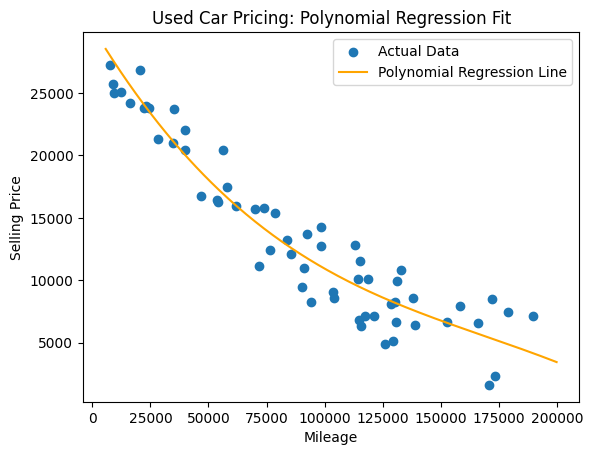

In [12]:
plt.scatter(X_test['mileage'], y_test, label='Actual Data')
plt.plot(x_range, y_range_pred, color='orange', label='Polynomial Regression Line')
plt.title('Used Car Pricing: Polynomial Regression Fit')
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.legend()
plt.show()